In [1]:
import os
import json
import re
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict
from langgraph.graph import StateGraph

In [2]:
load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

In [3]:
#state
class State(TypedDict):
    user_input: str
    data: dict
    missing: list

In [7]:
def extract(state):
    prompt = f"""
Extract beneficiary details.

Return ONLY valid JSON.

Fields:
name
phone
location
need
family_members

If missing, set null.

Example:
{{
    "name": null,
    "phone": null,
    "location": null,
    "need": null,
    "family_members": null
}}

Text:
{state['user_input']}
"""

    response = llm.invoke(prompt)

    content = response.content.strip()

    content = re.sub(r"```json|```", "", content).strip()

    print("LLM Output:", content)

    try:
        extracted = json.loads(content)
    except Exception as e:
        print("JSON Error:", e)
        extracted = {}

    data = state.get("data", {})
    data.update({k: v for k, v in extracted.items() if v})

    required = ["name", "phone", "need"]

    missing = [field for field in required if field not in data]

    return {
        "data": data,
        "missing": missing
    }

In [8]:
builder = StateGraph(State)

builder.add_node("extract", extract)

builder.set_entry_point("extract")

graph = builder.compile()

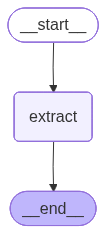

In [9]:
graph